In [4]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data_set=load_dataset('lukebarousse/data_jobs')
df = data_set['train'].to_pandas()
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
import ast
def clean_list(x):
    if pd.notna(x):
        return ast.literal_eval(x)
df['job_skills']=df['job_skills'].apply(clean_list)


In [55]:
df_us=df[df['job_country']=='United States'].copy()

In [5]:
df_skills=df.explode(['job_skills'])

In [60]:
df = df.drop_duplicates(subset=['job_title', 'job_location', 'job_via'])
df['job_id'] = df.index


df_skills = df.explode('job_skills')


df_skills_count = (
    df_skills
    .groupby(['job_title_short', 'job_skills'])['job_id']
    .nunique()
    .reset_index(name='skill_counts')
)
df_skills_count.sort_values(by='skill_counts', ascending=False, inplace=True)
df_skills_count

,job_title_short,job_skills,skill_counts
1054,Data Scientist,python,51752
854,Data Engineer,sql,48674
819,Data Engineer,python,46377
617,Data Analyst,sql,45186
1089,Data Scientist,sql,35631
...,...,...,...
1397,Senior Data Analyst,drupal,1
56,Business Analyst,f#,1
1400,Senior Data Analyst,electron,1
1401,Senior Data Analyst,elixir,1


In [61]:
job_titles=df_skills_count['job_title_short'].unique()
job_titles=sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

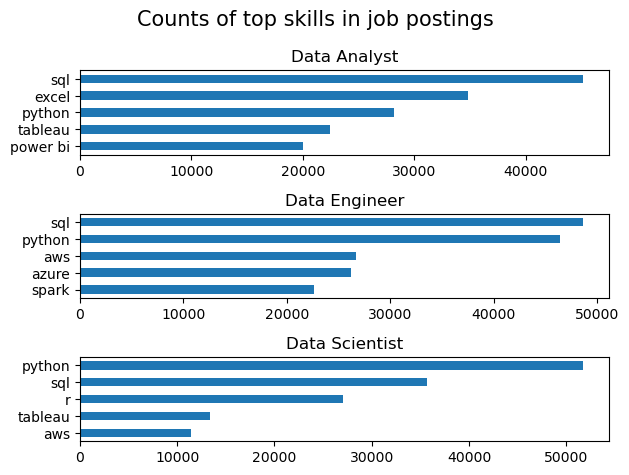

In [62]:
fig,ax=plt.subplots(len(job_titles),1)

for i,job_title in enumerate(job_titles):
    df_plot=df_skills_count[df_skills_count['job_title_short']==job_title].head(5)
    df_plot.plot(kind='barh',x='job_skills',y='skill_counts',ax=ax[i],title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().remove()

fig.suptitle('Counts of top skills in job postings',fontsize=15)   
fig.tight_layout()
    

In [66]:
df_job_title_counts=(
    df.groupby('job_title_short')['job_id']
    .nunique()
    .reset_index(name='job_total')
)
df_job_title_counts


,job_title_short,job_total
0,Business Analyst,32843
1,Cloud Engineer,9771
2,Data Analyst,104776
3,Data Engineer,85876
4,Data Scientist,84630
5,Machine Learning Engineer,8252
6,Senior Data Analyst,16179
7,Senior Data Engineer,18915
8,Senior Data Scientist,17531
9,Software Engineer,31898


In [67]:
df_skill_perc=pd.merge(df_skills_count,df_job_title_counts,how='left',on='job_title_short')

In [71]:
df_skill_perc['skill_perc']=100*(df_skill_perc['skill_counts']/df_skill_perc['job_total'])

In [72]:
df_skill_perc

,job_title_short,job_skills,skill_counts,job_total,skill_perc
0,Data Scientist,python,51752,84630,61.150892
1,Data Engineer,sql,48674,85876,56.679398
2,Data Engineer,python,46377,85876,54.004611
3,Data Analyst,sql,45186,104776,43.126288
4,Data Scientist,sql,35631,84630,42.102091
...,...,...,...,...,...
2213,Senior Data Analyst,drupal,1,16179,0.006181
2214,Business Analyst,f#,1,32843,0.003045
2215,Senior Data Analyst,electron,1,16179,0.006181
2216,Senior Data Analyst,elixir,1,16179,0.006181


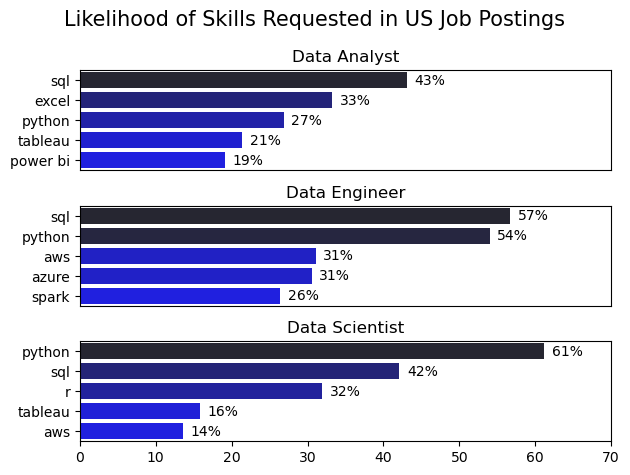

In [86]:
fig,ax=plt.subplots(len(job_titles),1)

for i,job_title in enumerate(job_titles):
    df_plot=df_skill_perc[df_skill_perc['job_title_short']==job_title].head(5)
    #df_plot.plot(kind='barh',x='job_skills',y='skill_perc',ax=ax[i],title=job_title)
    sns.barplot(data=df_plot, x='skill_perc', y='job_skills', ax=ax[i], hue='skill_counts', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().remove()
    ax[i].set_xlim(0,70)
    for n,v in enumerate(df_plot['skill_perc']):
        ax[i].text(v+1,n,f'{v:.0f}%',va='center')
    if i!=len(job_titles)-1:
        ax[i].set_xticks([])

fig.suptitle('Likelihood of Skills Requested in US Job Postings',fontsize=15)   
fig.tight_layout()
    